In [14]:
# All the code from the previous example

import pandas as pd
import seaborn as sns
ins_data = pd.read_csv("insurance.csv")
# In ML we divide the data in x(input values), y(output values)
x = ins_data.drop(columns = ["region", "charges"])
y = ins_data["charges"]
x.head()
# maping in the data
x["sex"].unique()
x["sex"] = x["sex"].map({"female": 1, "male": 0})
x["smoker"]= x["smoker"].map({"yes": 1, "no":0})
# Train test Split
import numpy as np
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)
# train the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
# Prediction values
predicted_values=model.predict(x_test)
# Evaluete the resutls
# R-squre values
from sklearn.metrics import r2_score
r2_value = r2_score(y_test, predicted_values)
print("r2 value is", r2_value)
# to get the adjusted r2 value
n = x_test.shape[0]
p = x_test.shape[1]

adjusted_r2 = 1 - ((1-r2_value)*(n-1)/(n-p-1))
print("the value of adjusted r2 is", adjusted_r2)


r2 value is 0.7811302113434097
the value of adjusted r2 is 0.7769533069797343


In [2]:
# Feature Engineering
# 1. One Hot Encoding

x = ins_data.drop(columns = ["charges"])
y = ins_data["charges"]
x = pd.get_dummies(x, columns = ["region"], drop_first = True, dtype = int)
x.head()
x["sex"] = x["sex"].map({"female": 1, "male": 0})
x["smoker"]= x["smoker"].map({"yes": 1, "no":0})
import numpy as np
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)#
from sklearn.metrics import r2_score
r2_value = r2_score(y_test, y_predict)
print("r2 value is", r2_value)


r2 value is 0.7835929767120724


In [3]:
# 2- Interaction Features
x = ins_data.drop(columns = ["charges"])
y = ins_data["charges"]
x = pd.get_dummies(x, columns = ["region"], drop_first = True, dtype = int)
x["sex"] = x["sex"].map({"female": 1, "male": 0})
x["smoker"]= x["smoker"].map({"yes": 1, "no":0})
x["smoke_age"] = x["smoker"] * x ["age"]
x["smoke_bmi"] = x["bmi"] * x ["smoker"]
print(x.head())

# again train the model after spliting the data

import numpy as np
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)#
from sklearn.metrics import r2_score
r2_value = r2_score(y_test, y_predict)
print("r2 value is", r2_value) # with feature interaction the value of r2 increase significantly

   age  sex     bmi  children  smoker  region_northwest  region_southeast  \
0   19    1  27.900         0       1                 0                 0   
1   18    0  33.770         1       0                 0                 1   
2   28    0  33.000         3       0                 0                 1   
3   33    0  22.705         0       0                 1                 0   
4   32    0  28.880         0       0                 1                 0   

   region_southwest  smoke_age  smoke_bmi  
0                 1         19       27.9  
1                 0          0        0.0  
2                 0          0        0.0  
3                 0          0        0.0  
4                 0          0        0.0  
r2 value is 0.865231697953168


In [4]:
# Underfit and Overfit
# underfit is when the r2 value is low for training as well as testing data
# overfit is when the r2 value is very high for training but low for testing data
# here we check weather our model is over or underfit 

y_train_pred = model.predict(x_train)
r2_train = r2_score(y_train, y_train_pred)
print("the value of r2 for training data is ", r2_train)
print("the value of r2 for test data is ", r2_value) # our model is quite good not over or underfit

the value of r2 for training data is  0.8340713711218875
the value of r2 for test data is  0.865231697953168


<Axes: >

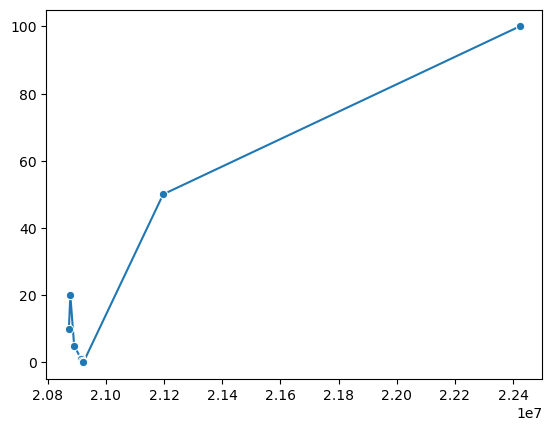

In [5]:
## Lasso Regression (L1 Regulization)
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import numpy as np
import seaborn as sns
al = [0.001, 0.009, 0.1, 0.5, 0.9, 1,1.2, 5, 10,20, 50, 100]
out = []
for i in al:
    lass_model = linear_model.Lasso(alpha=i)
    lass_model.fit(x_train, y_train)
    lass_prdic = lass_model.predict(x_test)
    mse = mean_squared_error(y_test, lass_prdic)
    out.append(mse)
sns.lineplot(x = out, y = al, marker="o")
# its the same process for the Ridge Regression (L2 regulization)
# this is the lame approach to get the best value of the alpha but actually we use cross validation to get the approperiate value of lembda. 

In [6]:
# Cross Validation
from sklearn.linear_model import LassoCV
al = [0.001, 0.009, 0.1, 0.5, 0.9, 1,1.2, 5, 10,20, 50, 100]
lass_cv = LassoCV(
    alphas = al, 
    cv = 5,
    max_iter = 1000, 
    random_state = 42) # cv define the numbers of folds, 
lass_cv.fit(x_train, y_train)
print("best alpha value is:", lass_cv.alpha_)

y_pred = lass_cv.predict(x_test)
mse_lass = mean_squared_error(y_test, y_pred)
print( "Mean Square value is :", mse_lass)
r2_value = r2_score(y_test, y_pred)
print("r2 value is :", r2_value)

best alpha value is: 0.001
Mean Square value is : 20922599.87103596
r2 value is : 0.8652317499151699


In [22]:
        ## Logistic Regression ModeL ##
##

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

In [23]:
data = pd.read_csv("heart.csv")
data.head()
data.info()
data.columns
data["target"].nunique()
data["target"]
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [24]:
# Define the x and y in the data
X = data.drop("target", axis = 1)
Y = data["target"]

In [29]:
# split the data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, z, test_size=0.2 ,random_state=42)


# it is very important to check in the data that the binary classification of test and train data should be fifty fifty or 60 40 
# otherwise our model will be biased.

#y_train[y_train == 1] 
#y_train[y_train == 1] # but it works after running the model


In [35]:
# implement the regression model
Log_Reg = LogisticRegression(max_iter = 1000)
Log_Reg.fit(X_train, Y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
Pred_y = Log_Reg.predict(X_test)

In [36]:
print("the accuracy of the model is", accuracy_score(Y_test, Pred_y))
print("the Precision value of the model is", precision_score(Y_test, Pred_y))

the accuracy of the model is 0.8852459016393442
the Precision value of the model is 0.8787878787878788


In [1]:
        ## Assignment Problem"


import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

In [6]:
ass_data = pd.read_csv("employee_turnover.csv")
ass_data.head()
#ass_data.info
#ass_data.describe
ass_data.columns
ass_data.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [9]:
xval = ass_data.drop("Employee_Turnover", axis =1) # here axis =1 means the selection of columns axis = 0 means rows
yval = ass_data["Employee_Turnover"]

In [10]:
# split the data
X_Train, X_Test, Y_Train, Y_Test = train_test_split(
    xval, yval, test_size=0.2, random_state=42)


In [31]:
# Implement the model

ass_model = LogisticRegression()
ass_model.fit(X_Train, Y_Train)
predy = ass_model.predict(X_Test)
print("the accuracy of the model is", accuracy_score(Y_Test, predy))
print("the Precision value of the model is", precision_score(Y_Test, predy))

the accuracy of the model is 0.8592592592592593
the Precision value of the model is 0.8717948717948718


In [33]:
# L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5)  # here we define the panalty to 1 for lasso regression)
# small C means Strong regularization → more features removed
# large C means Weak regularization → keeps more features

lasso.fit(X_Train, Y_Train)


,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [34]:
# L2 Regularization (Ridge)
# L2 Regularization (Ridge)
ridge = LogisticRegression(penalty='l2', C=1, max_iter=200)
ridge.fit(X_Train, Y_Train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [36]:
# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report

models = {'Baseline': ass_model, 'Lasso': lasso, 'Ridge': ridge}

for name, model in models.items():
    y_pred = model.predict(X_Test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(Y_Test, y_pred))
    print(classification_report(Y_Test, predy))


Baseline
Accuracy: 0.8592592592592593
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       145
           1       0.87      0.82      0.84       125

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270


Lasso
Accuracy: 0.8703703703703703
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       145
           1       0.87      0.82      0.84       125

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270


Ridge
Accuracy: 0.8592592592592593
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       145
           1       0.87      0.82      0.84       125

    accuracy                           0.86       270
   macro avg     